# Lab 0: Environment Check

Open this notebook from the `lab0_02_environment_setup` folder after completing the setup steps in `01_instructions.md`.

This notebook assumes your current working directory is this lab folder.

Before running the checks, make sure you copied `.env.example` to `.env` in this folder.

This notebook checks:
- Python and notebook paths
- required Python packages
- lab-local `.env` configuration
- Ollama endpoint connectivity
- Graphviz rendering


## Step 1: Confirm Your Notebook Paths

Run this cell to confirm which Python executable and working directory your notebook is using. It also checks that you opened the notebook from this lab folder and that this lab's `.env` and the repo `src/` folder can be found.


In [ ]:
from pathlib import Path
import sys

lab_dir = Path.cwd().resolve()
if lab_dir.name != 'lab0_02_environment_setup' or not (lab_dir / '03_environment_check.ipynb').exists():
    raise FileNotFoundError(
        'Open this notebook from the lab0_02_environment_setup folder.'
    )

repo_root = lab_dir.parent

env_example_path = lab_dir / '.env.example'
env_path = lab_dir / '.env'
src_path = repo_root / 'src'

print('Python executable:', sys.executable)
print('Current working directory:', lab_dir)
print('Detected repo root:', repo_root)
print('Detected lab folder:', lab_dir)
print('Lab .env exists:', env_path.exists())
print('Repo src exists:', src_path.exists())

if not env_example_path.exists():
    raise FileNotFoundError('Expected .env.example in the lab0_02_environment_setup folder.')

if not env_path.exists():
    raise FileNotFoundError('Expected .env in this folder. Copy .env.example to .env first.')

if not src_path.exists():
    raise FileNotFoundError('Expected src/ at the repo root.')


## Step 2: Check Required Python Packages

Run this cell to make sure the main Python packages for the labs are installed correctly. If an import fails here, stop and fix your environment before moving on.


In [2]:
import json
import requests
from dotenv import dotenv_values
from graphviz import Digraph
from openai import OpenAI

print('Required packages imported successfully.')


Required packages imported successfully.


## Step 3: Read Your `.env` Configuration

Run this cell to load `MODEL` and `OLLAMA_BASE_URL` from this lab's `.env` file. These values will be reused in the next setup checks.


In [3]:
config = dotenv_values(env_path)
model = config.get('MODEL')
ollama_base_url = config.get('OLLAMA_BASE_URL')

print('Env path:', env_path)
print('MODEL:', model)
print('OLLAMA_BASE_URL:', ollama_base_url)

if not model:
    raise ValueError("MODEL is missing from this lab's .env")

if not ollama_base_url:
    raise ValueError("OLLAMA_BASE_URL is missing from this lab's .env")


MODEL: qwen3.5:0.8b
OLLAMA_BASE_URL: http://localhost:11434/v1


## Step 4: Test the Ollama Model List Endpoint

Run this cell to contact the configured Ollama server and print the raw JSON response from the model-list endpoint. This confirms that the server is reachable.


In [4]:
tags_url = ollama_base_url.rstrip('/').replace('/v1', '/api/tags')

tags_response = requests.get(tags_url, timeout=10)
tags_response.raise_for_status()

response_data = tags_response.json()
print('Model list URL:', tags_url)
print('Full JSON response:')
print(json.dumps(response_data, indent=2))


Model list URL: http://localhost:11434/api/tags
Full JSON response:
{
  "models": [
    {
      "name": "gemma4:e4b",
      "model": "gemma4:e4b",
      "modified_at": "2026-04-04T16:47:22.806295904-04:00",
      "size": 9608350718,
      "digest": "c6eb396dbd5992bbe3f5cdb947e8bbc0ee413d7c17e2beaae69f5d569cf982eb",
      "details": {
        "parent_model": "",
        "format": "gguf",
        "family": "gemma4",
        "families": [
          "gemma4"
        ],
        "parameter_size": "8.0B",
        "quantization_level": "Q4_K_M"
      }
    },
    {
      "name": "huihui_ai/qwen3.5-abliterated:latest",
      "model": "huihui_ai/qwen3.5-abliterated:latest",
      "modified_at": "2026-03-15T19:07:49.99051198-04:00",
      "size": 17420432772,
      "digest": "e9ff39f1ea000e961c6e8be8165592dedc0d91eaf450169d55369d54cc86da0c",
      "details": {
        "parent_model": "",
        "format": "gguf",
        "family": "qwen35",
        "families": [
          "qwen35"
        ],
    

## Step 5: Check Whether Your Configured Model Is Available

Run this cell to extract the available model names from the server response and confirm that the model in your `.env` file is actually present.


In [5]:
models_data = response_data.get('models', [])

available_models = []
for item in models_data:
    model_name = item.get('name')
    if model_name:
        available_models.append(model_name)

print('Top-level keys in the JSON response:', list(response_data.keys()))
if models_data:
    print('Example model record from the response:')
    print(models_data[0])
print('Available models:', available_models)

if model not in available_models:
    raise ValueError(f"Model {model!r} was not found. Update this lab's .env or ask your instructor.")

print(f'Model {model!r} is available.')


Top-level keys in the JSON response: ['models']
Example model record from the response:
{'name': 'gemma4:e4b', 'model': 'gemma4:e4b', 'modified_at': '2026-04-04T16:47:22.806295904-04:00', 'size': 9608350718, 'digest': 'c6eb396dbd5992bbe3f5cdb947e8bbc0ee413d7c17e2beaae69f5d569cf982eb', 'details': {'parent_model': '', 'format': 'gguf', 'family': 'gemma4', 'families': ['gemma4'], 'parameter_size': '8.0B', 'quantization_level': 'Q4_K_M'}}
Available models: ['gemma4:e4b', 'huihui_ai/qwen3.5-abliterated:latest', 'qwen3.5:2b', 'qwen3.5:9b', 'qwen3.5:0.8b', 'qwen3.5:35b-a3b', 'qwen3:8b', 'qwen3.5:27b', 'llama3.3:70b']
Model 'qwen3.5:0.8b' is available.


## Step 6: Send a Simple Chat Request

Run this cell to send one small test message through Ollama's OpenAI-compatible API. If this works, your notebook can reach the configured model for the later labs.


The chat API expects a list called `messages`. Each item in that list is one message in the conversation. In this test, we send one message with `role='user'` and a short `content` prompt asking the model to reply with one exact sentence.


In [6]:
client = OpenAI(base_url=ollama_base_url, api_key='ollama')

chat_response = client.chat.completions.create(
    model=model,
    messages=[
        {
            'role': 'user',
            'content': 'If the model connection is working, reply with exactly: Your AI setup is working.'
        }
    ]
)

assistant_reply = chat_response.choices[0].message.content

print('Raw chat response object:')
print(chat_response)
print('Number of choices returned:', len(chat_response.choices))
print('Assistant reply:')
print(assistant_reply)


Raw chat response object:
ChatCompletion(id='chatcmpl-357', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Your AI setup is working.', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None, reasoning='Thinking Process:\n\n1.  **Analyze the Request:**\n    *   Constraint: The model connection is working.\n    *   Instruction: Reply with exactly: "Your AI setup is working."\n    *   Goal: Acknowledge the system state and comply with the specific output constraint.\n\n2.  **Safety Check:**\n    *   The prompt asks for a specific acknowledgment.\n    *   It does not ask for personal information, encourage malicious behavior, or trigger any restrictions (e.g., refusing the system request).\n    *   There are no sensitive topics requiring refusal here.\n    *   The instruction is benign.\n\n3.  **Safety Policy:**\n    *   The user request does not violate any safety policies. It\'s a direct form

## Step 7: Check Graphviz Rendering

Run this cell to render a small diagram in the notebook. If the diagram appears, your Graphviz setup is working.


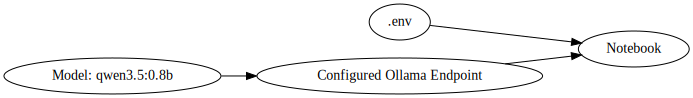

In [7]:
diagram = Digraph(comment='Setup Check')
diagram.attr(rankdir='LR')
diagram.node('env', '.env (this lab)')
diagram.node('ollama', 'Configured Ollama Endpoint')
diagram.node('model', f'Model: {model}')
diagram.node('nb', 'Notebook')
diagram.edges([('env', 'nb'), ('ollama', 'nb'), ('model', 'ollama')])
diagram


## Complete

If all cells run successfully, your environment is ready for Lab 1.